# 01. Обзор данных — M.Video Search / NER

Ноутбук описывает схему и базовые характеристики трёх источников:

1. `query_clicks.parquet` — клики по поисковой выдаче (~31M строк)
2. `sku_desc.parquet` — названия и описания SKU (~1.18M строк)
3. `skus.pkl` — YML-каталог (Yandex Market Language)

> Для скорости используем **семплы**; полные размеры датасетов фиксируем в статистике.


In [1]:
%matplotlib inline
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_utils import (
    apply_plot_style, save_fig, ensure_dirs, load_query_clicks, load_sku_desc,
    text_len, parquet_num_rows, parquet_schema_names, dataset_overview_stats,
    save_stats, QUERY_CLICKS_PATH, SKU_DESC_PATH, SKUS_PKL_PATH,
    MVIDEO_RED, DARK_SLATE, MUTED,
)

ensure_dirs()
apply_plot_style()
pd.set_option("display.max_colwidth", 80)
print("ROOT:", ROOT)


ROOT: D:\Projects-26-06-2026\mvideo-ner-search


## Полные размеры файлов


In [3]:
n_clicks = parquet_num_rows(QUERY_CLICKS_PATH)
n_desc = parquet_num_rows(SKU_DESC_PATH)
print(f"query_clicks.parquet: {n_clicks:,} строк")
print(f"sku_desc.parquet:     {n_desc:,} строк")
print(f"skus.pkl size:        {SKUS_PKL_PATH.stat().st_size / 1e9:.2f} GB")

print("\nСырые колонки query_clicks:")
for c in parquet_schema_names(QUERY_CLICKS_PATH):
    print(" -", c)

print("\nКолонки sku_desc:")
for c in parquet_schema_names(SKU_DESC_PATH):
    print(" -", c)


query_clicks.parquet: 30,991,350 строк
sku_desc.parquet:     1,177,200 строк
skus.pkl size:        1.57 GB

Сырые колонки query_clicks:
 - sku_id
 - toValidUTF8(sku_name)
 - toValidUTF8(sku_brand_name)
 - sku_price
 - sku_subject_id
 - sku_seo_id
 - toValidUTF8(query_text)
 - sku_position

Колонки sku_desc:
 - sku_id
 - title
 - description


## Семпл query_clicks

Колонки `toValidUTF8(...)` переименовываются в `sku_name`, `sku_brand_name`, `query_text`.


In [3]:
SAMPLE_N = 300_000
df = load_query_clicks(n=SAMPLE_N, seed=42, random=True)
print("Форма семпла:", df.shape)
print("\ndtypes:")
print(df.dtypes)
display(df.head(8))
display(df.describe(include="all").T)


Форма семпла: (300000, 8)

dtypes:
sku_id             uint64
sku_name           object
sku_brand_name     object
sku_price         float64
sku_subject_id     uint64
sku_seo_id         uint64
query_text         object
sku_position       uint64
dtype: object


,sku_id,sku_name,sku_brand_name,sku_price,sku_subject_id,sku_seo_id,query_text,sku_position
0,400032487,Раковина Orange OP-120RAL,Orange,20065.0,30774,30774,встраиваемая стиральная машинка узкая,19
1,4269933,Холодильник Midea MDRB523MGE33ODM,Midea,50999.0,17561,666,4269933,1
2,20033679,,,0.0,16291,2355,Вытяжки кухонные,0
3,400336695,,,9610.0,16713,1116,Xbox,0
4,4257324,,,143999.0,16435,914,Iphone 17 про 256,0
5,400390199,Картридж лазерный Cactus CS-TK5240BK,Cactus,643.0,16608,448,"Картридж Cactus CS-TK5240BK, TK-5240BK, черный / CS-TK5240BK",1
6,400764726,,,2156.0,17354,1008,Зарядное устройство samsungТа 800,0
7,400398603,,,110740.0,16266,495,Встраиваемые холодильники,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sku_id,300000.0,NaN,NaN,NaN,290155379.858453,172669503.830688,1.0,30093350.0,400412297.0,400570294.0,402068575.0
sku_name,300000,61381,,64933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_brand_name,300000,3527,,84813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_price,300000.0,NaN,NaN,NaN,30767.256573,70361.141572,0.0,4842.0,15999.0,37635.0,5689000.0
sku_subject_id,300000.0,NaN,NaN,NaN,19248.788173,7687.834409,0.0,16401.0,16774.0,17561.0,62214.0
sku_seo_id,300000.0,NaN,NaN,NaN,5640.350217,12155.878227,0.0,679.0,987.0,2447.0,62168.0
query_text,300000,79889,стиральная машинка,4641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_position,300000.0,NaN,NaN,NaN,16.78305,43.393828,0.0,1.0,4.0,16.0,2101.0


## Пропуски и пустые строки


,nulls,empty_str,null_or_empty_share
sku_id,0,0,0.000000
sku_name,0,64933,0.216443
sku_brand_name,0,84813,0.282710
sku_price,0,0,0.000000
sku_subject_id,0,0,0.000000
sku_seo_id,0,0,0.000000
query_text,0,0,0.000000
sku_position,0,0,0.000000


Сохранено: C:\Users\kamau\Documents\мвидео\figures\16_nulls_overview.png


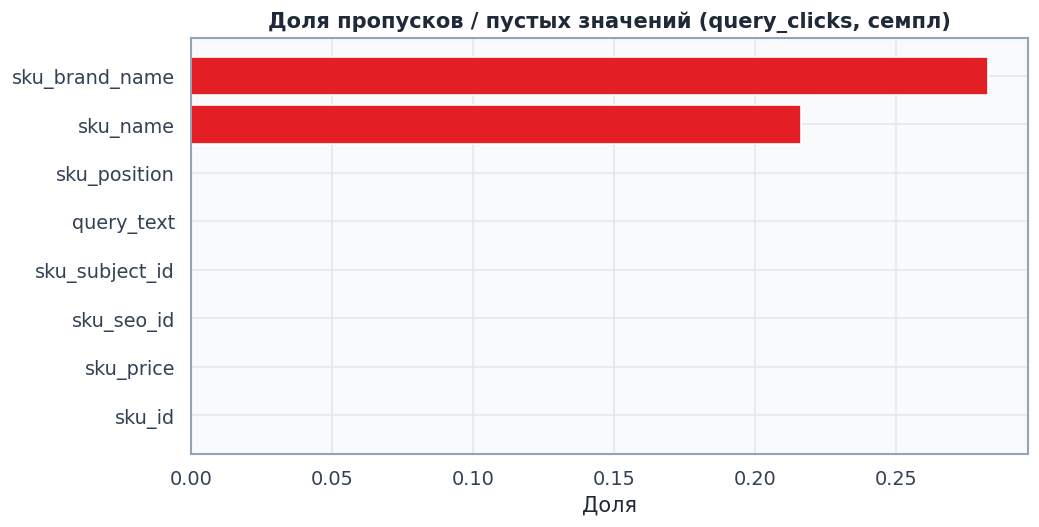

In [4]:
nulls = df.isna().sum()
empty = (df.astype(str).eq("") | df.astype(str).eq("nan")).sum()
overview = pd.DataFrame({"nulls": nulls, "empty_str": empty, "null_or_empty_share": (nulls + empty) / len(df)})
display(overview)
fig, ax = plt.subplots(figsize=(9, 4.5))
share = overview["null_or_empty_share"].sort_values()
ax.barh(share.index, share.values, color=MVIDEO_RED)
ax.set_title("Доля пропусков / пустых значений (query_clicks, семпл)")
ax.set_xlabel("Доля")
save_fig(fig, "16_nulls_overview.png")
plt.show()


## Семпл sku_desc


In [5]:
desc = load_sku_desc(n=200_000, seed=42, random=True)
print("Форма:", desc.shape)
print(desc.dtypes)
display(desc.head(5))
print("\nПропуски:")
print(desc.isna().sum())
print("\nПустые title:", (desc["title"].fillna("").eq("")).sum())
print("Пустые description:", (desc["description"].fillna("").eq("")).sum())


Форма: (200000, 3)
sku_id          int64
title          object
description    object
dtype: object


,sku_id,title,description
0,401614439,Коврик для мыши PANiN Коврик для мыши 22x18 FP215734497,"Коврик для мыши — это не просто аксессуар, а незаменимый инструмент для комф..."
1,401295434,Штора для ванной 365home Штора для ванной 180х180см / Акварельный фон: размытые,Штора для ванной 365home с рисунком - Акварельный фон: размытые розовые и го...
2,401740869,Робот GSS -,Игрушка-трансформер Мэджик Бист Лев 14см.\n\nХарактеристики:\n• Эффекты: тра...
3,30041562,Смартфон teXet TM-5075 черный,"Смартфон teXet TM-5075 – отличный выбор для нетребовательного пользователя, ..."
4,401422578,Духи БестПарфюм World,"Масляные духи по мотивам Kenzo World ( Кензо Ворлд, Кензо Глаз Голубой ) - э..."



Пропуски:
sku_id         0
title          0
description    0
dtype: int64

Пустые title: 0


Пустые description: 0


## Структура skus.pkl (YML)

Файл большой (~1.5 GB). Загрузка может занять несколько минут.


In [6]:
import pickle
with open(SKUS_PKL_PATH, "rb") as f:
    skus = pickle.load(f)
print(type(skus))
if isinstance(skus, dict):
    print("Ключи:", list(skus.keys())[:30])
    cat = skus.get("yml_catalog", skus)
    if isinstance(cat, dict):
        print("yml_catalog keys:", list(cat.keys())[:30])
        shop = cat.get("shop", {})
        if isinstance(shop, dict):
            print("shop keys:", list(shop.keys())[:40])


<class 'dict'>
Ключи: ['yml_catalog']
yml_catalog keys: ['@date', 'shop']
shop keys: ['categories', 'offers']


## Ключевые статистики → artifacts


In [7]:
stats = dataset_overview_stats(df)
stats["known_full_unique_queries_approx"] = 1_790_000
stats["known_full_unique_skus_approx"] = 332_000
stats["known_full_unique_brands_approx"] = 7150
stats["known_full_unique_subjects_approx"] = 4103
stats["sample_top_queries"] = df["query_text"].value_counts().head(10).to_dict()
stats["sample_top_brands"] = (
    df["sku_brand_name"].replace("", np.nan).dropna().value_counts().head(10).to_dict()
)
save_stats(stats)
stats


Статистика сохранена: C:\Users\kamau\Documents\мвидео\artifacts\dataset_stats.json


{'query_clicks_full_rows': 30991350,
 'sku_desc_full_rows': 1177200,
 'query_clicks_columns_raw': ['sku_id',
  'toValidUTF8(sku_name)',
  'toValidUTF8(sku_brand_name)',
  'sku_price',
  'sku_subject_id',
  'sku_seo_id',
  'toValidUTF8(query_text)',
  'sku_position'],
 'sku_desc_columns': ['sku_id', 'title', 'description'],
 'skus_pkl_size_bytes': 1565150311,
 'sample_rows': 300000,
 'sample_unique_queries': 79889,
 'sample_unique_skus': 73645,
 'sample_unique_brands': 3527,
 'sample_unique_subjects': 2063,
 'sample_price_median': 15999.0,
 'sample_price_mean': 30767.256573333332,
 'sample_null_counts': {'sku_id': 0,
  'sku_name': 0,
  'sku_brand_name': 0,
  'sku_price': 0,
  'sku_subject_id': 0,
  'sku_seo_id': 0,
  'query_text': 0,
  'sku_position': 0},
 'known_full_unique_queries_approx': 1790000,
 'known_full_unique_skus_approx': 332000,
 'known_full_unique_brands_approx': 7150,
 'known_full_unique_subjects_approx': 4103,
 'sample_top_queries': {'стиральная машинка': 4641,
  'холоди